In [1]:
#all imports necessary for the project
import numpy as np
import cv2
import os
import tensorflow as tf

from tensorflow.keras import layers, models, Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import load_model

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#configuring image size and batch size for tthe model, compatible with MobileNetV2
IMAGE_SIZE = (224, 224)
IMAGE_FULL_SIZE = (224, 224, 3)
BATCH_SIZE = 8 # the batch size is small due to technical limitations

In [3]:
#dataset paths to the downloaded image folders containing the training and testing images
trainImgfolder = "C:/Users/marto/OneDrive - Budapesti Műszaki és Gazdaságtudományi Egyetem/ML/priject/pp/dogImages/train"
testImgfolder = "C:/Users/marto/OneDrive - Budapesti Műszaki és Gazdaságtudományi Egyetem/ML/priject/pp/dogImages/test"
validImgfolder = "C:/Users/marto/OneDrive - Budapesti Műszaki és Gazdaságtudományi Egyetem/ML/priject/pp/dogImages/valid"

#tensorflow datast loader
def load_image_dataset(
    trainImgfolder,
    img_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    categorical=True,
    shuffle=True
):
    label_mode = "categorical" if categorical else "int" # formatting thelabels to one-hot (integer) labels
#loading the dataset from the folders and formattign the images to the desired size, and batch size, also shuffling the imaes for better ttraining
    ds = tf.keras.utils.image_dataset_from_directory(
        trainImgfolder,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        label_mode=label_mode,
        shuffle=shuffle
    )


#extracting thhe class names(dog breeds)
    class_names = ds.class_names
    return ds, class_names


In [4]:
#loads the test dataset as tensorflow dataset with the same format as the training dataset
test_ds, class_names = load_image_dataset(
    testImgfolder,
    categorical=True,
    shuffle=True
)

Found 836 files belonging to 133 classes.


In [5]:
#manual dataset loader used for training
def load_dataset(root_dir, img_size=(224, 224)):
    X = [] #images
    y = []  #labels
    class_names = []
#iterating over each class folder
    for class_name in sorted(os.listdir(root_dir)):
        class_path = os.path.join(root_dir, class_name)

        if not os.path.isdir(class_path):
            continue

        class_names.append(class_name)
        label = len(class_names) - 1 #assigning numerical label

#loading all images from the lass folder
        for fname in os.listdir(class_path):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            path = os.path.join(class_path, fname)
#reading image using OpenCV
            img = cv2.imdecode(np.fromfile(path, dtype=np.uint8), cv2.IMREAD_COLOR)

            if img is None:
                continue
#converting BGR-> RGB as openCV uses BGR by default, resize to model input size
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size)

            X.append(img)
            y.append(label)
#normalizepixel values to [0,1] for stable NN training, convert to float16 to save memory, and convert labels to int32
    X = np.array(X, dtype=np.float16) / 255.0
    y = np.array(y, dtype=np.int32)

    return X, y, class_names 

In [6]:
#loading datasets into memory
X_train, y_train, class_names = load_dataset(trainImgfolder)
X_test, y_test, _ = load_dataset(testImgfolder)
X_val, y_val, _ = load_dataset(validImgfolder)

#checking dataset shapes to make sure they are loaded correctly
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(6679, 224, 224, 3)
(836, 224, 224, 3)
(835, 224, 224, 3)


In [7]:
#number of classes (dog breeds)
numOfCategories = len(np.unique(y_train))
print(numOfCategories)

133


In [8]:
#MoobilNetV2 pretrained model used to exttract features (transfer learnign)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMAGE_FULL_SIZE,
    include_top=False, #remoe classification head
    weights='imagenet' #use pretrained weights
)
#freezing convolutional base to prevent overfitting
base_model.trainable = False
#custom clssificationhead 
model = models.Sequential([
    base_model,
    #convert feature maps
    layers.GlobalAveragePooling2D(),
    #regularization toreduce overfitting
    layers.Dropout(0.4),
    #final classiffier output layer with softmax activation
    layers.Dense(numOfCategories, activation='softmax')
])

#compiling the model using ADAM optimizer with a low learning rate
model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 133)            │       170,373 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,357 (9.26 MB)

 Trainable params: 170,373 (665.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
numOfCategories = len(np.unique(y_train))

#convertin integer labels as categorical format is required for sftmax training
y_train_cat = to_categorical(y_train, num_classes=numOfCategories)
y_test_cat  = to_categorical(y_test, num_classes=numOfCategories)
y_val_cat  = to_categorical(y_val, num_classes=numOfCategories)

# compile model
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

In [ ]:
#saving the best models weight for testing later and callbacks for early stopping and learning rate reduction
best_model_file = "C:/temp/dogs/best_model.h5"

callbacks = [
    #save when model validation improves
    ModelCheckpoint(best_model_file, save_best_only=True, verbose=1),
    #raducing learning rate on plateau to avoid overshooting the minimum
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.1,
        patience=3,
        verbose=1,
        min_lr=1e-7
    ),
    #early stopping to prevent overffitting
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        verbose=1,
        restore_best_weights=True
    )
]

#model training
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=40,
    batch_size=BATCH_SIZE,
    callbacks=callbacks  
)

In [10]:
#loading the best model
model = load_model("C:/temp/dogs/best_model.h5")

#recompiling
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

#evaluate accuracy on the test set
loss, accuracy = model.evaluate(X_test, y_test_cat)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

#predict class probabilities for test images
predictions = model.predict(X_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 34s 865ms/step - accuracy: 0.8230 - loss: 0.6402
Test Loss: 0.6402
Test Accuracy: 0.8230
27/27 ━━━━━━━━━━━━━━━━━━━━ 28s 925ms/step


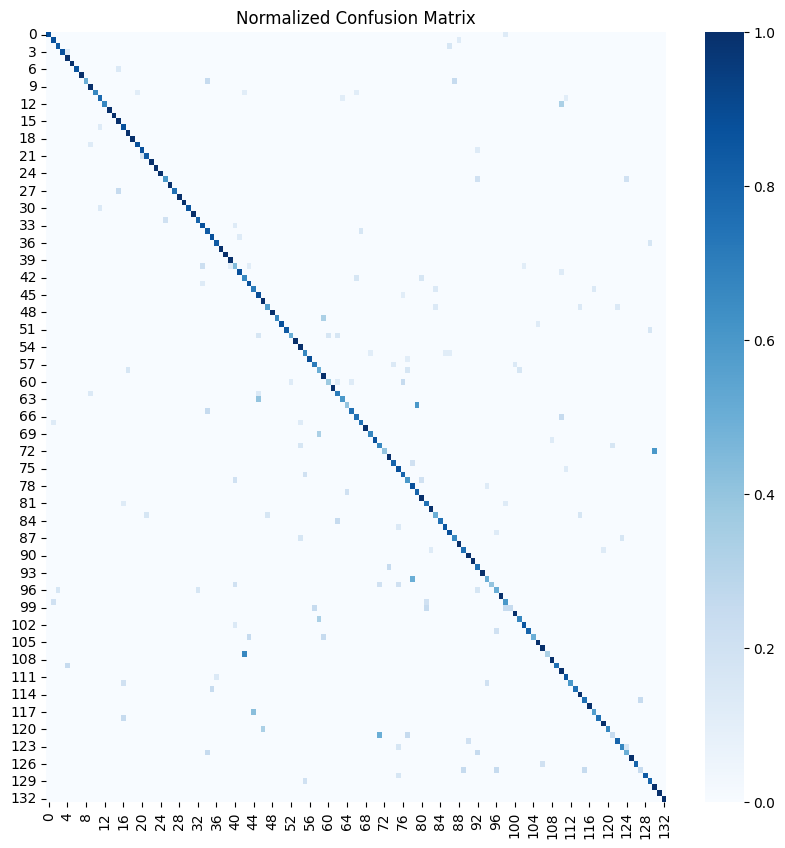

In [11]:
y_pred = np.argmax(predictions, axis=1)
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10,10))
sns.heatmap(cm_norm, cmap='Blues')
plt.title("Normalized Confusion Matrix")
plt.show()

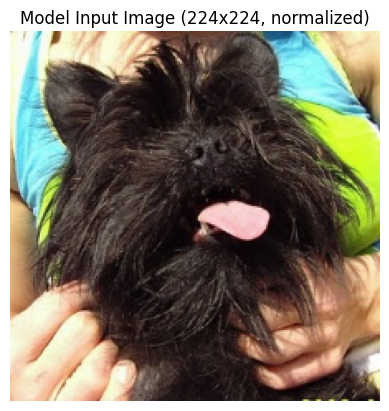

Shape: (224, 224, 3)
Min: 0.0
Max: 1.0


In [ ]:
#selecting a sample image from the test dataset, converting imagge to floaat32 to match the format expected by the  model
img = X_test[0].astype(np.float32)

#display the image fed into the classifier
plt.imshow(img)
plt.title("Model Input Image (224x224, normalized)")
plt.axis("off")
plt.show()

#veryfying the image dimensions and the normalization range
print("Shape:", img.shape)
print("Min:", np.min(img))
print("Max:", np.max(img))

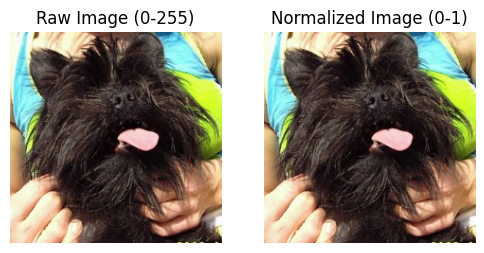

Pixel at (100, 100): [0.12158203 0.06665039 0.06274414]


In [ ]:
#convert the normalized image back to original 0-255 pixel range to compare raw and normalied forms
img_raw = (img * 255).astype(np.uint8)

plt.figure(figsize=(6,3))

#original pixel representation
plt.subplot(1,2,1)
plt.imshow(img_raw)
plt.title("Raw Image (0-255)")
plt.axis("off")

#normalized image representation
plt.subplot(1,2,2)
plt.imshow(img)
plt.title("Normalized Image (0-1)")
plt.axis("off")

plt.show()

#pixel value before and after normalization
print("Pixel at (100, 100):", img[100,100])

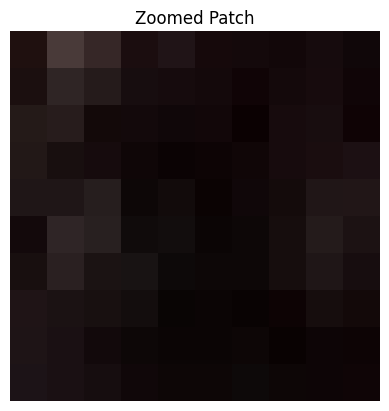

[[[0.12158203 0.06665039 0.06274414]
  [0.28637695 0.23132324 0.22741699]
  [0.21179199 0.15686035 0.1529541 ]
  [0.105896   0.05490112 0.05883789]
  [0.12939453 0.08233643 0.09020996]
  [0.08630371 0.03921509 0.04705811]
  [0.08233643 0.03530884 0.04315186]
  [0.07061768 0.03137207 0.03530884]
  [0.08630371 0.04705811 0.05099487]
  [0.06665039 0.03137207 0.03530884]]

 [[0.105896   0.06274414 0.06274414]
  [0.18823242 0.1451416  0.1451416 ]
  [0.1451416  0.105896   0.105896  ]
  [0.09020996 0.05490112 0.05883789]
  [0.08630371 0.04705811 0.05099487]
  [0.08233643 0.03921509 0.04315186]
  [0.06665039 0.01960754 0.02745056]
  [0.08233643 0.03530884 0.04315186]
  [0.09411621 0.04705811 0.05490112]
  [0.06665039 0.02352905 0.03137207]]

 [[0.14123535 0.10198975 0.09802246]
  [0.1529541  0.1137085  0.1137085 ]
  [0.07452393 0.03530884 0.03921509]
  [0.07452393 0.03921509 0.04315186]
  [0.06665039 0.03137207 0.03530884]
  [0.07061768 0.03137207 0.03921509]
  [0.04705811 0.00784302 0.0117645

In [ ]:
#extracting a small patch from the image to visualize local features
#this is a 10 by 10 patch from the image
patch = img[100:110, 100:110]

plt.imshow(patch)
plt.title("Zoomed Patch")
plt.axis("off")
plt.show()

#raw pixel values of the patchbefore normalization
print(patch)

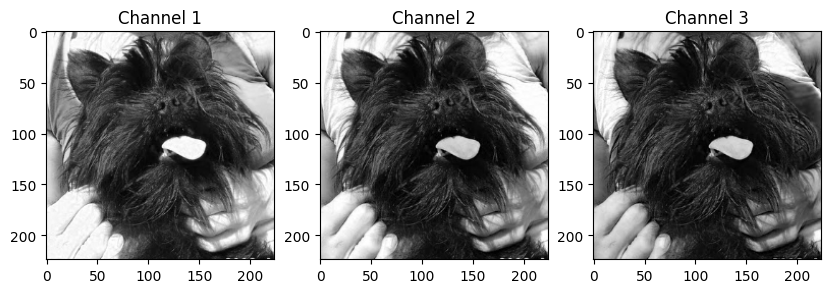

In [ ]:
#separating te RGB channels individually to illustrate how contour helps preserve information
plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.imshow(img[:,:,0], cmap='gray')
plt.title("Channel 1")

plt.subplot(1,3,2)
plt.imshow(img[:,:,1], cmap='gray')
plt.title("Channel 2")

plt.subplot(1,3,3)
plt.imshow(img[:,:,2], cmap='gray')
plt.title("Channel 3")

plt.show()

In [ ]:
#creating models to show the activations of the MobilNetV2 assifier
input_layer = tf.keras.Input(shape=(224, 224, 3))

#forward pass
x = model.layers[0](input_layer)   # MobileNetV2
feature_output = x

#forward pass through thhe global average pooling layer
x = model.layers[1](x)             # GAP
gap_output = x

#models for extracting intermediate outputs
feature_model = tf.keras.Model(inputs=input_layer, outputs=feature_output)
gap_model = tf.keras.Model(inputs=input_layer, outputs=gap_output)

#generatingfeaure maps ad pooled feature vectors
features = feature_model.predict(img[None,...])
vector = gap_model.predict(img[None,...])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


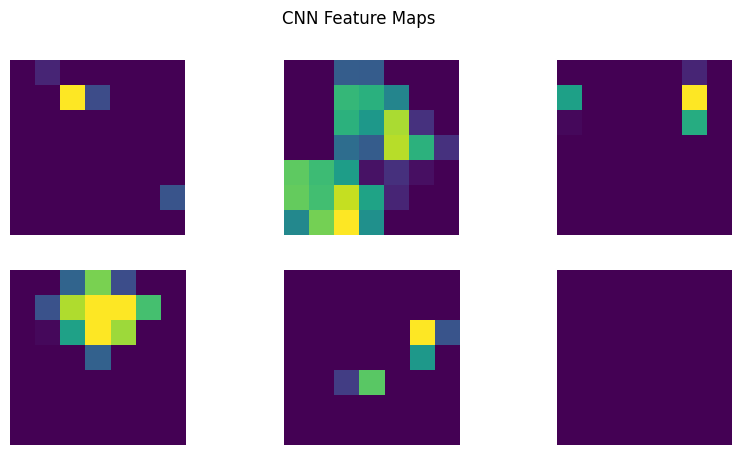

In [ ]:
#displayig feature maps produced by the CNN, highlighting regions the network considers important for classification
plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(features[0,:,:,i], cmap='viridis')
    plt.axis('off')

plt.suptitle("CNN Feature Maps")
plt.show()

Vector shape: (1, 1280)
Vector values: [[0.05417679 1.7595259  0.14115447 ... 0.80354667 0.33223373 0.01503493]]


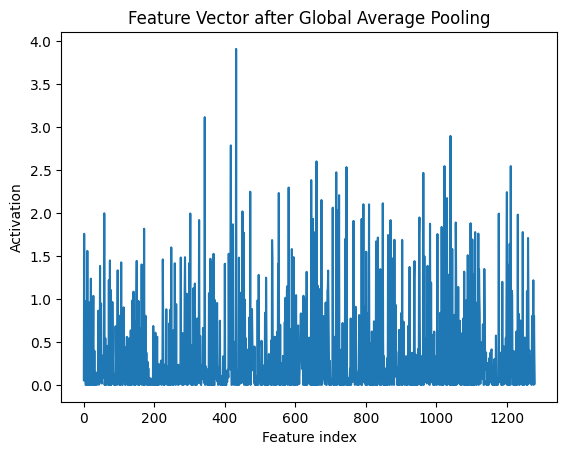

In [ ]:
#showing feature vector generated after global average pooling
print("Vector shape:", vector.shape)
print("Vector values:", vector)

#visualize activation strengths across features
plt.plot(vector[0])
plt.title("Feature Vector after Global Average Pooling")
plt.xlabel("Feature index")
plt.ylabel("Activation")
plt.show()

In [28]:
pred = model.predict(img[None,...])
pred_class = np.argmax(pred)

print("Predicted:", class_names[pred_class])
print("Confidence:", np.max(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
Predicted: 001.Affenpinscher
Confidence: 0.9025744
